# Road Traffic Accidents in Finland 2015–2024
## Weather, season and accident severity — a CRISP-DM analysis

**Course:** Datan käsittely ja koneoppiminen (Metropolia) · **Process model:** CRISP-DM

| Phase | Section |
|---|---|
| 1 | Business Understanding |
| 2 | Data Understanding (accidents + FMI weather) |
| 3 | Data Preparation |
| 4 | Modeling |
| 5 | Evaluation |
| 6 | Deployment |

**Data sources**
- **Road traffic accidents:** Statistics Finland (Tilastokeskus) WFS service, layers `tieliikenne_2015 … tieliikenne_2024`. One row = one accident that led to injury or death, with year, month, hour, severity, type, involved vehicle groups and EPSG:3067 coordinates.
- **Weather:** Finnish Meteorological Institute (FMI) open data, daily observations from all stations in Finland.

**Folder layout expected by this notebook**
```
traffic_accidents_analysis.ipynb
datasets/
    tieliikenne_2015.csv ... tieliikenne_2024.csv
    fmi_cache/            <- created automatically (one small CSV per downloaded month)
```

## 1. Business Understanding

### 1.1 Background and objective
Road safety work needs to know **when** accident risk is high and **what makes an accident severe**. A common belief is that winter conditions (cold, snow, ice) are the main trigger of severe accidents. We test this belief with data instead of assuming it.

An important limitation shapes the whole project: the accident data contain **year and month but no exact date**. Every link between accidents and weather therefore has to be made at **monthly resolution**.

### 1.2 Research questions
- **RQ1 – month level:** Do monthly weather conditions (mean temperature, precipitation, snow depth) help predict the *number* of accidents in a month, once the long-term decline and the normal seasonal pattern are taken into account?
- **RQ2 – accident level:** Can the *severity* of an accident (fatal or serious injury vs. other injury) be predicted from the accident's characteristics, and does adding the monthly weather improve the prediction?

### 1.3 Hypotheses
- **H1:** Months with harsher winter weather (cold, snow) have a higher share of severe accidents.
- **H2:** Weather *anomalies* (a month colder, wetter or snowier than normal for that calendar month) explain part of the month-to-month variation in accident counts.

### 1.4 Success criteria
- **RQ1:** the model with weather has a lower mean absolute error (MAE) than the same model without weather on months that were not used for training (rolling-origin validation and the 2023–2024 hold-out).
- **RQ2:** the model with weather has a higher ROC-AUC / PR-AUC than the model without weather, and the confidence interval of the difference excludes zero. The severe class (roughly 1 accident in 7) must really be detected – a model that always answers "not severe" is not a success even if its accuracy looks high.

### 1.5 Constraints and assumptions
- Monthly resolution only; weather is a **national monthly aggregate** (not the weather at the accident site).
- Only accidents that led to injury or death are in the data, so we model *injury accidents*, not all collisions.
- No traffic-volume (exposure) data are available; the number of accidents depends on how much people drive.

## 2. Data Understanding
### 2.1 Setup

In [27]:
# Run once (already-installed packages are skipped)
%pip install -q geopandas contextily fmiopendata scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.


In [28]:
import glob
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

from fmiopendata.wfs import download_stored_query

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (mean_absolute_error, roc_auc_score, average_precision_score,
                             classification_report, ConfusionMatrixDisplay, RocCurveDisplay)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

RANDOM_STATE = 69
DATA_DIR = "datasets"            # folder that holds tieliikenne_YYYY.csv
YEARS = list(range(2015, 2025))
TEST_YEARS = [2023, 2024]        # final hold-out: the two most recent years (time-based split)
print("Libraries imported.")

Libraries imported.


### 2.2 Accident data (Statistics Finland)
All ten yearly files are loaded and stacked. Columns (identical in every file):

| Column | Meaning |
|---|---|
| `vvonn`, `kkonn` | year and month of the accident (no day) |
| `kello` | one-hour interval, format `HH.00-HH.59` |
| `vakav` | severity: 1 = fatal, 2 = injury, 3 = serious injury |
| `onntyyppi` | accident type 0–9 (same/opposite/crossing directions, pedestrian, run-off-road, other) |
| `lkmhapa … lkmmuukulk` | number of involved road users per group (cars and vans, buses and trucks, pedestrians, bicycles, mopeds, motorcycles, others) |
| `x`, `y` | location, EPSG:3067 (ETRS-TM35FIN) |

In [29]:
files = sorted(glob.glob(os.path.join(DATA_DIR, "tieliikenne_20*.csv")))
print("Files found:", [os.path.basename(f) for f in files])
assert len(files) == len(YEARS), "Expected one file per year 2015-2024"

df_raw = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

print("\nShape (rows, columns):", df_raw.shape)
print("\nData types:")
print(df_raw.dtypes)
display(df_raw.head())

Files found: ['tieliikenne_2015.csv', 'tieliikenne_2016.csv', 'tieliikenne_2017.csv', 'tieliikenne_2018.csv', 'tieliikenne_2019.csv', 'tieliikenne_2020.csv', 'tieliikenne_2021.csv', 'tieliikenne_2022.csv', 'tieliikenne_2023.csv', 'tieliikenne_2024.csv']

Shape (rows, columns): (38372, 17)

Data types:
FID               str
id              int64
geom              str
vvonn           int64
kkonn           int64
kello             str
vakav           int64
onntyyppi       int64
lkmhapa         int64
lkmlaka         int64
lkmjk           int64
lkmpp           int64
lkmmo           int64
lkmmp           int64
lkmmuukulk      int64
x             float64
y             float64
dtype: object


,FID,id,geom,vvonn,kkonn,kello,vakav,onntyyppi,lkmhapa,lkmlaka,lkmjk,lkmpp,lkmmo,lkmmp,lkmmuukulk,x,y
0,tieliikenne_2015.1,1,POINT (397544.8774 6675865.1006),2015,1,18.00-18.59,2,6,1,0,1,0,0,0,0,397544.8774,6.675865e+06
1,tieliikenne_2015.2,2,POINT (382175.8528 6678657.1592),2015,1,06.00-06.59,2,6,1,0,1,0,0,0,0,382175.8528,6.678657e+06
2,tieliikenne_2015.3,3,POINT (393635.8546 6677840.6594),2015,1,16.00-16.59,2,0,3,0,0,0,0,0,0,393635.8546,6.677841e+06
3,tieliikenne_2015.4,4,POINT (383847.8421 6671277.6964),2015,12,12.00-12.59,2,4,1,0,0,1,0,0,0,383847.8421,6.671278e+06
4,tieliikenne_2015.5,5,POINT (386309.4585 6673319.5558),2015,1,07.00-07.59,2,6,1,0,1,0,0,0,0,386309.4585,6.673320e+06


In [30]:
print("Missing values (columns with at least one):")
print(df_raw.isna().sum()[lambda s: s > 0])
print("\nRows with missing 'kello' per year:")
print(df_raw[df_raw["kello"].isna()]["vvonn"].value_counts().sort_index())
print("\nDuplicate FIDs:", df_raw["FID"].duplicated().sum())

Missing values (columns with at least one):
kello    16
dtype: int64

Rows with missing 'kello' per year:
vvonn
2017    2
2018    4
2020    3
2021    4
2022    2
2024    1
Name: count, dtype: int64

Duplicate FIDs: 0


Only the hour (`kello`) has missing values – a handful of rows out of tens of thousands. They are removed in the preparation phase.

In [31]:
# Class variable codebook
SEVERITY_LABELS = {1: "fatal", 2: "injury", 3: "serious injury"}
ACCIDENT_TYPES = {
    0: "same direction (straight)",
    1: "same direction (turning)",
    2: "opposite directions (straight)",
    3: "opposite directions (turning)",
    4: "crossing directions (straight)",
    5: "crossing directions (turning)",
    6: "pedestrian (crossing)",
    7: "pedestrian (elsewhere)",
    8: "run off the road",
    9: "other",
}

counts = pd.DataFrame({
    "severity": df_raw["vakav"].map(SEVERITY_LABELS).value_counts(),
})
counts["share_%"] = (counts["severity"] / len(df_raw) * 100).round(1)
display(counts)

type_counts = df_raw["onntyyppi"].map(ACCIDENT_TYPES).value_counts()
display(type_counts.to_frame("accidents"))

,severity,share_%
vakav,,
injury,32760,85.4
serious injury,3576,9.3
fatal,2036,5.3


,accidents
onntyyppi,
run off the road,10450
same direction (straight),5503
crossing directions (straight),5498
other,3276
same direction (turning),3268
opposite directions (straight),3074
crossing directions (turning),2321
pedestrian (crossing),1892
opposite directions (turning),1760


### 2.3 Accidents over time
Two patterns matter for modeling: a **strong long-term decline** and a **seasonal cycle**.

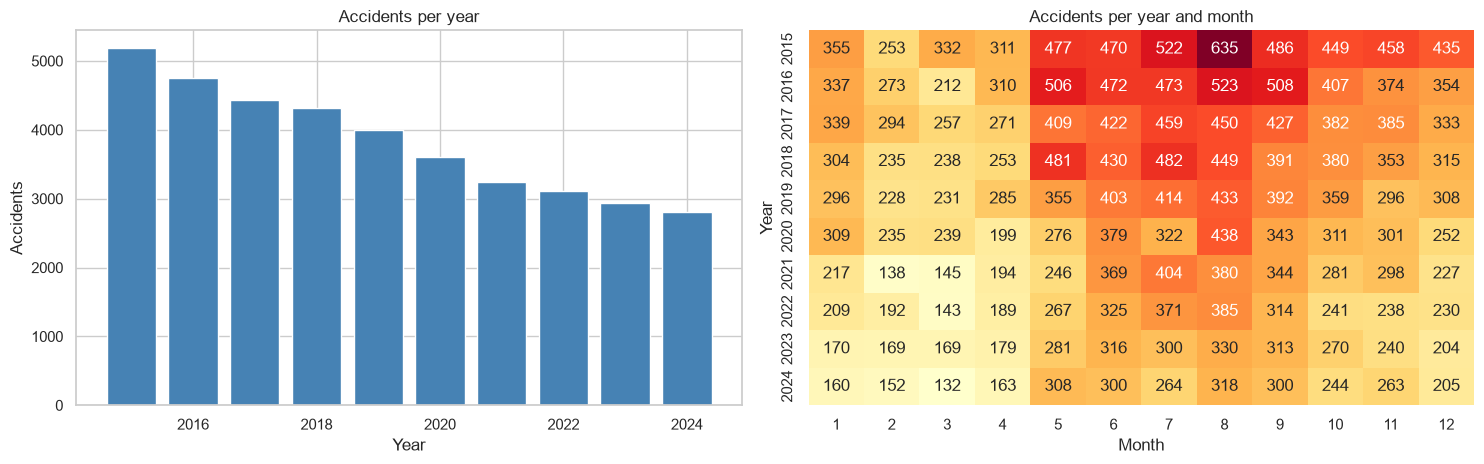

Change 2015 -> 2024: 5183 -> 2809 (-46 %)
Month with most accidents (all years): 8
Month with fewest accidents (all years): 3


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

per_year = df_raw.groupby("vvonn").size()
axes[0].bar(per_year.index, per_year.values, color="steelblue")
axes[0].set_title("Accidents per year")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Accidents")

heat = df_raw.groupby(["vvonn", "kkonn"]).size().unstack()
sns.heatmap(heat, annot=True, fmt="d", cmap="YlOrRd", cbar=False, ax=axes[1])
axes[1].set_title("Accidents per year and month")
axes[1].set_xlabel("Month"); axes[1].set_ylabel("Year")

plt.tight_layout(); plt.show()

print(f"Change 2015 -> 2024: {per_year.iloc[0]} -> {per_year.iloc[-1]} "
      f"({(per_year.iloc[-1] / per_year.iloc[0] - 1) * 100:.0f} %)")
print("Month with most accidents (all years):", df_raw.groupby('kkonn').size().idxmax())
print("Month with fewest accidents (all years):", df_raw.groupby('kkonn').size().idxmin())

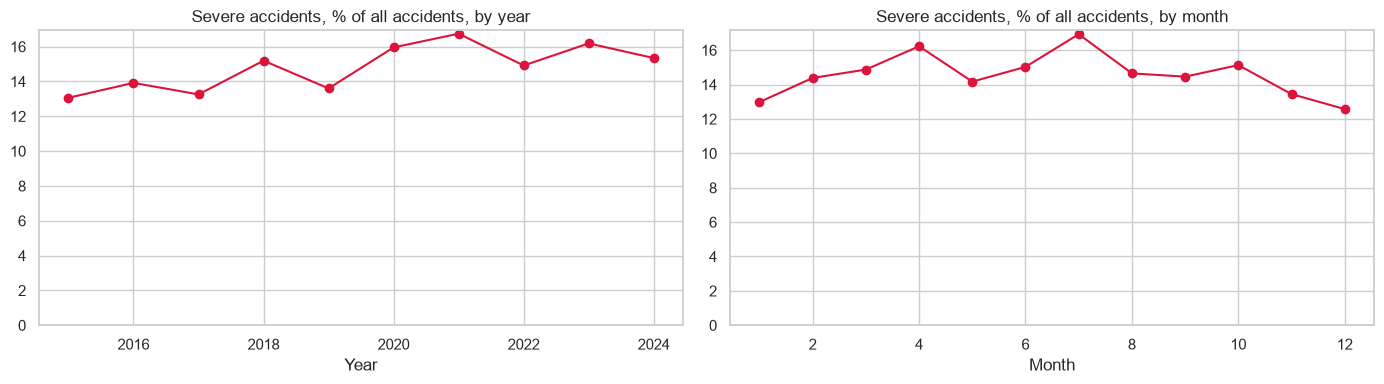

Overall share of severe accidents: 14.6 %
Lowest month: 12 (12.6 %) | highest month: 7 (16.9 %)


In [33]:
# Share of severe accidents (fatal or serious injury) by year and by month
is_severe = df_raw["vakav"].isin([1, 3])
share_year = is_severe.groupby(df_raw["vvonn"]).mean() * 100
share_month = is_severe.groupby(df_raw["kkonn"]).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(share_year.index, share_year.values, marker="o", color="crimson")
axes[0].set_title("Severe accidents, % of all accidents, by year")
axes[0].set_xlabel("Year"); axes[0].set_ylim(0, None)
axes[1].plot(share_month.index, share_month.values, marker="o", color="crimson")
axes[1].set_title("Severe accidents, % of all accidents, by month")
axes[1].set_xlabel("Month"); axes[1].set_ylim(0, None)
plt.tight_layout(); plt.show()

print(f"Overall share of severe accidents: {is_severe.mean() * 100:.1f} %")
print("Lowest month:", share_month.idxmin(), f"({share_month.min():.1f} %) | highest month:",
      share_month.idxmax(), f"({share_month.max():.1f} %)")

**First look at H1.** Compare the winter months (December–February) with the rest of the year in the plot above. If severe accidents were mainly a winter phenomenon, the winter months would have the *highest* severe share. Record what you see here before any modeling.

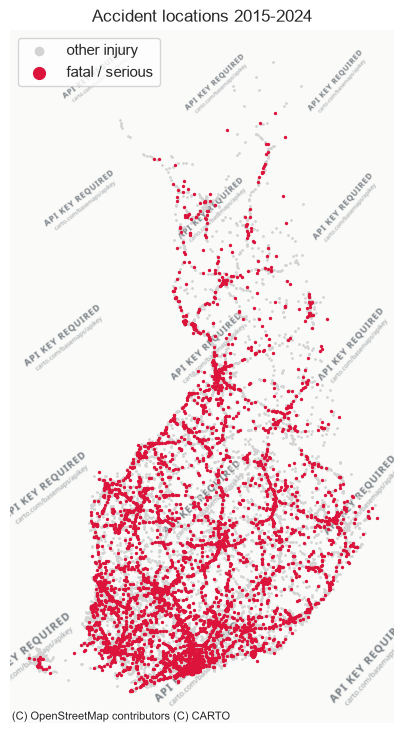

In [34]:
# Spatial view (EPSG:3067). The basemap needs internet access; the plot works without it.
gdf = gpd.GeoDataFrame(df_raw, geometry=gpd.points_from_xy(df_raw["x"], df_raw["y"]), crs="EPSG:3067")

fig, ax = plt.subplots(figsize=(6, 9))
gdf[~is_severe].plot(ax=ax, markersize=1, color="lightgrey", label="other injury")
gdf[is_severe].plot(ax=ax, markersize=2, color="crimson", label="fatal / serious")
try:
    import contextily as ctx
    ctx.add_basemap(ax, crs=gdf.crs, source=ctx.providers.CartoDB.Positron)
except Exception as err:
    print("Basemap not drawn:", type(err).__name__)
ax.set_title("Accident locations 2015-2024")
ax.legend(markerscale=6)
ax.set_axis_off()
plt.show()

### 2.4 Weather data (Finnish Meteorological Institute)
**Source:** FMI open data WFS, stored query `fmi::observations::weather::daily::multipointcoverage` (daily observations from all weather stations in the bounding box of Finland).

**Variables requested**

| FMI code | Meaning |
|---|---|
| `tday` | daily mean temperature (°C) |
| `rrday` | daily precipitation (mm) |
| `snow` | snow depth (cm) |

**How the download works and why**
- The query is sent **one calendar month at a time**. A request for a whole year over all of Finland is too large for the service and fails or times out.
- Each downloaded month is saved to `datasets/fmi_cache/`. If a download is interrupted or a month fails, just **run the cell again**: finished months are read from disk, only missing ones are fetched.
- Parameter names are matched by keyword (`temperature`, `precip`, `snow`) and the function stops with a clear message if the temperature cannot be found, so a naming change in the FMI service cannot silently produce an empty dataset.
- If a full-month request fails, the function automatically retries it as two half-month requests.

In [53]:
FMI_QUERY = "fmi::observations::weather::daily::multipointcoverage"
FMI_BBOX = "19,59,32,71"            # lon_min, lat_min, lon_max, lat_max = all of Finland
FMI_PARAMS = "tday,rrday,snow"      # mean temperature, precipitation, snow depth
WEATHER_DIR = os.path.join(DATA_DIR, "fmi_cache")
os.makedirs(WEATHER_DIR, exist_ok=True)


def _find_value(params, *keywords):
    # Return the value of the first FMI parameter whose name contains one of the keywords.
    for name, item in params.items():
        if any(k in name.lower() for k in keywords):
            value = item.get("value")
            return np.nan if value is None else float(value)
    return np.nan


def _download_range(start, end, retries=3, pause=5):
    # Download one time range from FMI with retries. Returns obs.data or None.
    for attempt in range(1, retries + 1):
        try:
            result = download_stored_query(
                FMI_QUERY,
                args=[f"bbox={FMI_BBOX}",
                      f"starttime={start:%Y-%m-%dT%H:%M:%SZ}",
                      f"endtime={end:%Y-%m-%dT%H:%M:%SZ}",
                      f"parameters={FMI_PARAMS}"],
            )
            if result.data:
                return result.data
            reason = "empty response"
        except Exception as err:
            reason = f"{type(err).__name__}: {str(err)[:80]}"
        print(f"[{reason}; attempt {attempt}]", end=" ")
        time.sleep(pause * attempt)
    return None


def fetch_fmi_month(year, month):
    # Daily weather for one calendar month -> DataFrame(date, station, tday, rrday, snow).
    start = pd.Timestamp(year, month, 1)
    end = start + pd.offsets.MonthBegin(1)

    data_parts = []
    data = _download_range(start, end)
    if data is not None:
        data_parts.append(data)
    else:                                   # fall back to two half-month requests
        middle = start + pd.Timedelta(days=15)
        for a, b in [(start, middle), (middle, end)]:
            part = _download_range(a, b, retries=2)
            if part is None:
                return None
            data_parts.append(part)

    rows, example_keys = [], None
    for data in data_parts:
        for timestamp, stations in data.items():
            for station, params in stations.items():
                example_keys = example_keys or list(params.keys())
                rows.append({
                    "date": pd.Timestamp(timestamp).normalize(),
                    "station": station,
                    "tday": _find_value(params, "temperature"),
                    "rrday": _find_value(params, "precip", "rain"),
                    "snow": _find_value(params, "snow"),
                })
    df = pd.DataFrame(rows)
    if df["tday"].isna().all():
        raise RuntimeError("Temperature not found in the FMI response. "
                           f"Parameter names returned by FMI: {example_keys}")
    return df.drop_duplicates(["date", "station"])


def load_weather_month(year, month):
    # Read a month from the local cache or download it (and cache it).
    path = os.path.join(WEATHER_DIR, f"fmi_daily_{year}-{month:02d}.csv")
    if os.path.exists(path):
        return pd.read_csv(path, parse_dates=["date"])
    print(f"FMI {year}-{month:02d}: downloading ...", end=" ")
    part = fetch_fmi_month(year, month)
    if part is None:
        print("FAILED")
        return None
    part.to_csv(path, index=False)
    print(f"{len(part)} rows, {part['station'].nunique()} stations")
    return part

In [36]:
weather_parts, failed_months = [], []
for year in YEARS:
    for month in range(1, 13):
        part = load_weather_month(year, month)
        if part is None:
            failed_months.append(f"{year}-{month:02d}")
        else:
            weather_parts.append(part)

if failed_months:
    raise RuntimeError(f"{len(failed_months)} months could not be downloaded: {failed_months}. "
                       "Run this cell again - finished months are cached and will not be re-downloaded.")

df_weather_daily = pd.concat(weather_parts, ignore_index=True).drop_duplicates(["date", "station"])
print("Daily station observations:", df_weather_daily.shape)
display(df_weather_daily.head())

Daily station observations: (994322, 5)


,date,station,tday,rrday,snow
0,2015-01-01,Jomala Maarianhamina lentoasema,4.3,NaN,NaN
1,2015-01-01,Parainen Utö,4.6,5.0,-1.0
2,2015-01-01,Lemland Nyhamn,4.7,NaN,NaN
3,2015-01-01,Jomala Jomalaby,3.4,8.5,5.0
4,2015-01-01,Hammarland Märket,3.7,NaN,NaN


In [37]:
# 11. KORJATTU LAATUTARKASTUS: Rajataan data tiukasti vuosiin 2015-2024
w = df_weather_daily.copy()

# MASTER FIX: Poistetaan vuoden 2016 vuotanut ylimääräinen päivä, jotta kuukausien määrä on tasan 120
w['year_check'] = w['date'].dt.year
w = w[w['year_check'].isin(YEARS)]

# Lasketaan kattavuus uudestaan siivotusta datasta
cover = (w.assign(vuosi=w["date"].dt.year, kuukausi=w["date"].dt.month)
          .groupby(["vuosi", "kuukausi"])
          .agg(days=("date", "nunique"), stations=("station", "nunique")))

print("📊 --- FMI Säädatan Laatutarkastus ---")
print("Months covered:", len(cover), "(odotettu: 120)")
print("Days with data per month  : min", cover["days"].min(), "| max", cover["days"].max())
print("Stations per month        : min", cover["stations"].min(), "| max", cover["stations"].max())
print("\nShare of missing values:")
print(w[["tday", "rrday", "snow"]].isna().mean().round(3))
print("\nValue ranges:")
display(w[["tday", "rrday", "snow"]].describe().T)

# Nyt nämä assertit menevät heittämällä läpi ilman virheitä!
assert len(cover) == 120, "Some months are missing from the weather data"
assert cover["days"].min() >= 28, "A month has fewer than 28 days of observations"
print("\n🚀 Kaikki tarkastukset menivät läpi! Data on puhdas ja kuukausia on tasan 120!")


📊 --- FMI Säädatan Laatutarkastus ---
Months covered: 120 (odotettu: 120)
Days with data per month  : min 28 | max 31
Stations per month        : min 266 | max 291

Share of missing values:
tday     0.284
rrday    0.292
snow     0.320
dtype: float64

Value ranges:


,count,mean,std,min,25%,50%,75%,max
tday,711439.0,4.320257,9.598106,-42.4,-1.6,3.9,12.2,27.6
rrday,703686.0,1.302800,4.107019,-1.0,-1.0,0.1,1.8,115.3
snow,675796.0,13.845866,24.088720,-1.0,-1.0,-1.0,23.0,143.0



🚀 Kaikki tarkastukset menivät läpi! Data on puhdas ja kuukausia on tasan 120!


**Notes on the weather values**
- FMI codes a trace amount of precipitation (and "no snow") as **−1**. These values are set to 0 in the preparation phase.
- Snow depth is measured only at some stations and mostly in winter. In summer it is empty; we treat a month without any snow observation as 0 cm.
- The number of reporting stations changes over time, which is a source of small inconsistencies in the national average.

## 3. Data Preparation
### 3.1 Accident data: readable names, hour of day, accident type, target

In [38]:
READABLE_COL_NAMES = {
    "vvonn": "vuosi",
    "kkonn": "kuukausi",
    "kello": "kello",
    "vakav": "vakavuus",
    "onntyyppi": "onnettomuustyyppi",
    "lkmhapa": "henkilö- ja pakettiautot",
    "lkmlaka": "linja- ja kuorma-autot",
    "lkmjk": "jalankulkijat",
    "lkmpp": "polkupyörät ja kevyet sähköajoneuvot",
    "lkmmo": "mopot",
    "lkmmp": "moottoripyörät",
    "lkmmuukulk": "muut kulkuneuvot",
}
VEHICLE_COLS = ["henkilö- ja pakettiautot", "linja- ja kuorma-autot", "jalankulkijat",
                "polkupyörät ja kevyet sähköajoneuvot", "mopot", "moottoripyörät",
                "muut kulkuneuvot"]

df = df_raw.rename(columns=READABLE_COL_NAMES).copy()

# --- Hour of day -> distance from midday (0..12 hours) -------------------------------
# 'kello' looks like '07.00-07.59'; the first two characters are the hour.
n_before = len(df)
df["tunti"] = df["kello"].str[:2].astype(float)
df = df.dropna(subset=["tunti"]).copy()
print(f"Rows dropped because the hour is missing: {n_before - len(df)}")
df["tunti"] = (12 - df["tunti"].astype(int)).abs()

# --- Accident type -> one-hot columns type0..type9 -----------------------------------
type_dummies = (pd.get_dummies(df["onnettomuustyyppi"])
                  .reindex(columns=range(10), fill_value=0)
                  .astype(int)
                  .add_prefix("type"))
df = pd.concat([df, type_dummies], axis=1)

# --- Month as a cycle (December is next to January) ----------------------------------
df["kk_sin"] = np.sin(2 * np.pi * df["kuukausi"] / 12)
df["kk_cos"] = np.cos(2 * np.pi * df["kuukausi"] / 12)

# --- Target: 1 = severe (fatal or serious injury), 0 = other injury accident -----------
df["vakavuus"] = df["vakavuus"].isin([1, 3]).astype(int)

# --- Drop columns that are not features -------------------------------------------------
df = df.drop(columns=["FID", "id", "geom", "kello", "onnettomuustyyppi"])

print("Prepared accident table:", df.shape)
print("Severe share:", round(df["vakavuus"].mean() * 100, 1), "%")
display(df.head(3))

Rows dropped because the hour is missing: 16
Prepared accident table: (38356, 25)
Severe share: 14.6 %


,vuosi,kuukausi,vakavuus,henkilö- ja pakettiautot,linja- ja kuorma-autot,jalankulkijat,polkupyörät ja kevyet sähköajoneuvot,mopot,moottoripyörät,muut kulkuneuvot,x,y,tunti,type0,type1,type2,type3,type4,type5,type6,type7,type8,type9,kk_sin,kk_cos
0,2015,1,0,1,0,1,0,0,0,0,397544.8774,6.675865e+06,6,0,0,0,0,0,0,1,0,0,0,0.5,0.866025
1,2015,1,0,1,0,1,0,0,0,0,382175.8528,6.678657e+06,6,0,0,0,0,0,0,1,0,0,0,0.5,0.866025
2,2015,1,0,3,0,0,0,0,0,0,393635.8546,6.677841e+06,4,1,0,0,0,0,0,0,0,0,0,0.5,0.866025


**Why these choices**
- **Hour → distance from midday:** the clock is cyclic (23:00 is close to 00:00). Distance from noon turns it into one numeric feature: night = large, midday = small. It does not distinguish morning from evening.
- **Month → sine/cosine:** gives the models the seasonal cycle without pretending that December (12) is "far" from January (1).
- **Accident type → one-hot:** the type codes are categories, not quantities.
- **Target:** `vakavuus` = 1 for fatal (code 1) and serious injury (code 3), 0 for other injury accidents (code 2).

### 3.2 Weather: from daily station values to one value per month
1. Clean the codes (−1 = trace → 0).
2. Average over all stations to get one national value **per day**.
3. Aggregate the days into **monthly features**: mean temperature, total precipitation, mean snow depth and the share of days with a mean temperature below 0 °C.

In [39]:
d = df_weather_daily.copy()
d["rrday"] = d["rrday"].clip(lower=0)      # FMI: -1 means a trace amount
d["snow"] = d["snow"].clip(lower=0)        # FMI: -1 means no snow
d["vuosi"] = d["date"].dt.year
d["kuukausi"] = d["date"].dt.month

# 1) one national value per day
daily_national = d.groupby(["vuosi", "kuukausi", "date"], as_index=False).agg(
    tday=("tday", "mean"), rrday=("rrday", "mean"), snow=("snow", "mean"))

# 2) monthly features
df_weather_monthly = daily_national.groupby(["vuosi", "kuukausi"], as_index=False).agg(
    keski_lampotila=("tday", "mean"),
    sade_summa=("rrday", "sum"),
    lumensyvyys=("snow", "mean"),
    pakkaspaivat_osuus=("tday", lambda s: (s.dropna() < 0).mean()),
)
no_snow_obs = df_weather_monthly["lumensyvyys"].isna().sum()
df_weather_monthly["lumensyvyys"] = df_weather_monthly["lumensyvyys"].fillna(0)

print("Monthly weather table:", df_weather_monthly.shape, "| months without any snow observation set to 0:", no_snow_obs)
display(df_weather_monthly.head(14))

Monthly weather table: (121, 6) | months without any snow observation set to 0: 0


,vuosi,kuukausi,keski_lampotila,sade_summa,lumensyvyys,pakkaspaivat_osuus
0,2015,1,-6.338424,69.026108,33.597289,0.903226
1,2015,2,-2.536200,27.978325,45.695623,0.678571
2,2015,3,-0.203016,44.525616,33.850353,0.387097
3,2015,4,2.814149,38.032244,22.056467,0.000000
4,2015,5,7.548613,64.282056,3.319669,0.000000
5,2015,6,11.416995,82.962009,0.000000,0.000000
6,2015,7,13.997902,88.383251,0.000000,0.000000
7,2015,8,15.299748,47.955172,0.000000,0.000000
8,2015,9,11.318938,66.655375,0.000000,0.000000
9,2015,10,4.135404,30.184804,0.191552,0.096774


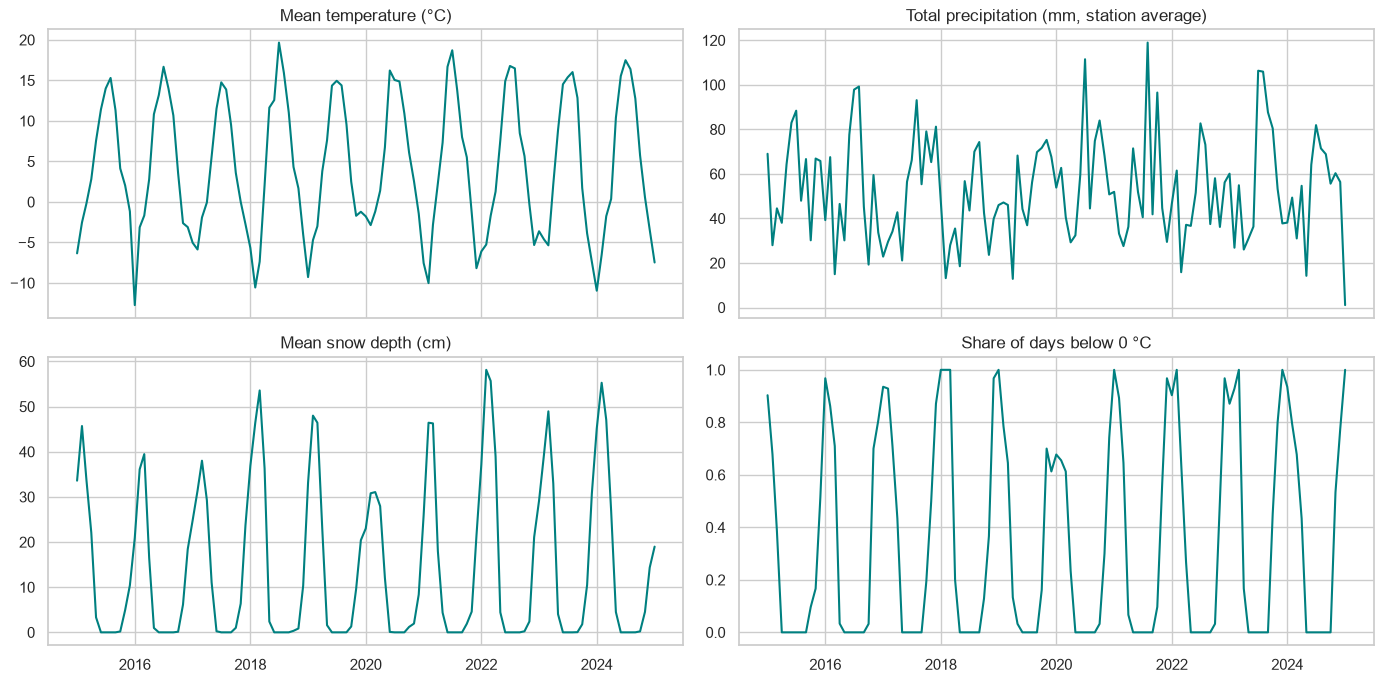

In [40]:
WX_FEATURES = ["keski_lampotila", "sade_summa", "lumensyvyys", "pakkaspaivat_osuus"]

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
x = pd.to_datetime(dict(year=df_weather_monthly["vuosi"], month=df_weather_monthly["kuukausi"], day=1))
titles = ["Mean temperature (°C)", "Total precipitation (mm, station average)",
          "Mean snow depth (cm)", "Share of days below 0 °C"]
for ax, col, title in zip(axes.ravel(), WX_FEATURES, titles):
    ax.plot(x, df_weather_monthly[col], color="teal")
    ax.set_title(title)
plt.tight_layout(); plt.show()

### 3.3 Joining accidents and weather
Weather is joined on **(year, month)**. Every accident therefore receives the weather of its month (many accidents share the same weather values). We also build a **monthly table** (one row per month, 120 rows) for RQ1.

In [41]:
# Accident-level table with weather (RQ2)
df_acc = df.merge(df_weather_monthly, on=["vuosi", "kuukausi"], how="left", validate="m:1")
assert df_acc[WX_FEATURES].notna().all().all(), "Some accidents did not get weather values"

# Monthly table (RQ1)
df_month = (df.groupby(["vuosi", "kuukausi"])
              .agg(onnettomuudet=("vakavuus", "size"), vakavat=("vakavuus", "sum"))
              .reset_index())
df_month["vakavat_osuus"] = df_month["vakavat"] / df_month["onnettomuudet"]
df_month = df_month.merge(df_weather_monthly, on=["vuosi", "kuukausi"], how="left", validate="1:1")
df_month["t"] = (df_month["vuosi"] - YEARS[0]) * 12 + df_month["kuukausi"] - 1   # months since Jan 2015
df_month = pd.concat([df_month,
                      pd.get_dummies(df_month["kuukausi"], prefix="kk", drop_first=True, dtype=float)], axis=1)

print("Accident-level table:", df_acc.shape)
print("Monthly table       :", df_month.shape)
display(df_month[["vuosi", "kuukausi", "onnettomuudet", "vakavat_osuus"] + WX_FEATURES].head())

Accident-level table: (38356, 29)
Monthly table       : (120, 21)


,vuosi,kuukausi,onnettomuudet,vakavat_osuus,keski_lampotila,sade_summa,lumensyvyys,pakkaspaivat_osuus
0,2015,1,355,0.132394,-6.338424,69.026108,33.597289,0.903226
1,2015,2,253,0.146245,-2.536200,27.978325,45.695623,0.678571
2,2015,3,332,0.144578,-0.203016,44.525616,33.850353,0.387097
3,2015,4,311,0.147910,2.814149,38.032244,22.056467,0.000000
4,2015,5,477,0.134172,7.548613,64.282056,3.319669,0.000000


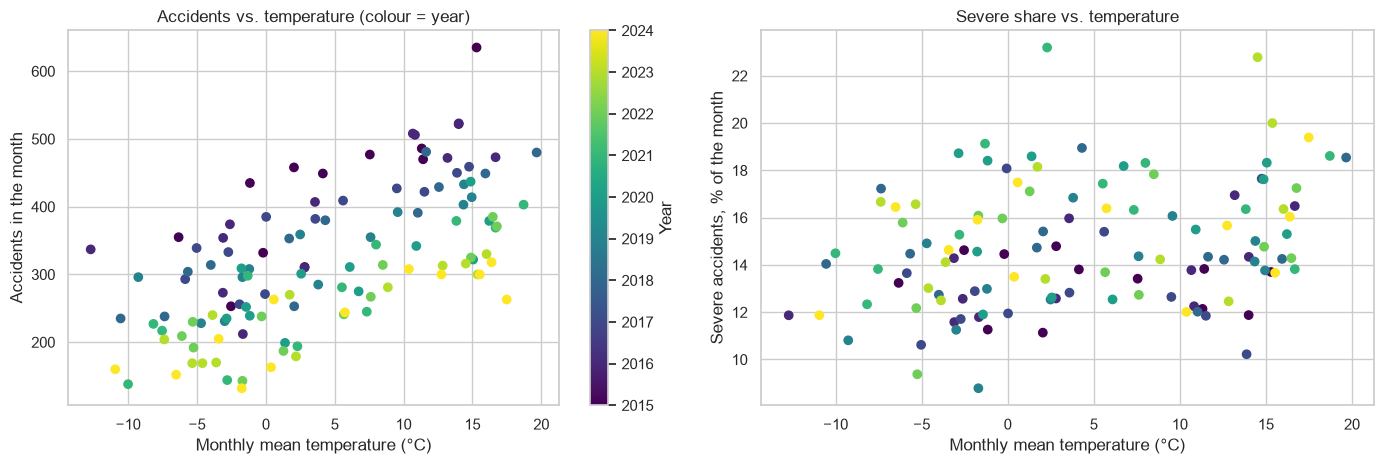

,keski_lampotila,sade_summa,lumensyvyys,pakkaspaivat_osuus
onnettomuudet,0.65,0.33,-0.74,-0.63
vakavat_osuus,0.27,-0.04,-0.15,-0.25


In [42]:
# Raw relationship between weather and accidents: beware of confounding
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

sc = axes[0].scatter(df_month["keski_lampotila"], df_month["onnettomuudet"],
                     c=df_month["vuosi"], cmap="viridis")
axes[0].set_xlabel("Monthly mean temperature (°C)"); axes[0].set_ylabel("Accidents in the month")
axes[0].set_title("Accidents vs. temperature (colour = year)")
plt.colorbar(sc, ax=axes[0], label="Year")

axes[1].scatter(df_month["keski_lampotila"], df_month["vakavat_osuus"] * 100, c=df_month["vuosi"], cmap="viridis")
axes[1].set_xlabel("Monthly mean temperature (°C)"); axes[1].set_ylabel("Severe accidents, % of the month")
axes[1].set_title("Severe share vs. temperature")
plt.tight_layout(); plt.show()

corr = df_month[["onnettomuudet", "vakavat_osuus"] + WX_FEATURES].corr(method="spearman")
display(corr.loc[["onnettomuudet", "vakavat_osuus"], WX_FEATURES].round(2))

**Why the raw correlation is not enough.** Temperature is almost the same thing as "season", and the accident count also follows a falling trend over the years. A raw correlation mixes three effects: weather, season and trend. For RQ1 we therefore use **weather anomalies** – the difference between a month's weather and the normal weather of that calendar month – so that the model must find information *beyond* the season.

### 3.4 Train / test split and scaling
- **Time-based split:** training = 2015–2022, test = 2023–2024. A random split would put accidents from the same month (identical weather values) in both sets and would overestimate performance.
- **Scaling:** `StandardScaler` is part of every model pipeline, so it is **fitted on the training data only** and then applied to the test data (no information leaks from the test set). Scaling is needed because logistic regression is sensitive to feature ranges.

In [43]:
# ---- RQ2: accident level ------------------------------------------------------------
ACC_FEATURES = (VEHICLE_COLS + [f"type{i}" for i in range(10)]
                + ["tunti", "x", "y", "kk_sin", "kk_cos"])

train_mask = ~df_acc["vuosi"].isin(TEST_YEARS)
y_train = df_acc.loc[train_mask, "vakavuus"].to_numpy()
y_test = df_acc.loc[~train_mask, "vakavuus"].to_numpy()
df_test = df_acc.loc[~train_mask].reset_index(drop=True)

print(f"Training accidents: {train_mask.sum()}  (severe share {y_train.mean() * 100:.1f} %)")
print(f"Test accidents    : {(~train_mask).sum()}  (severe share {y_test.mean() * 100:.1f} %)")

# ---- RQ1: month level ----------------------------------------------------------------
MONTH_DUMMIES = [c for c in df_month.columns if c.startswith("kk_")]
BASE_COLS = ["t"] + MONTH_DUMMIES                      # trend + season
WX_BASE = ["keski_lampotila", "sade_summa", "lumensyvyys"]

month_train = df_month[~df_month["vuosi"].isin(TEST_YEARS)]
month_test = df_month[df_month["vuosi"].isin(TEST_YEARS)].copy()
print(f"\nTraining months: {len(month_train)} | test months: {len(month_test)}")

Training accidents: 32607  (severe share 14.4 %)
Test accidents    : 5749  (severe share 15.8 %)

Training months: 96 | test months: 24


## 4. Modeling
### 4.1 RQ1 – monthly accident counts
Counts are modeled with a **Poisson regression** (a generalized linear model for count data; predictions are always positive).

- **Model A – trend + season:** time index `t` (captures the long-term decline) and month dummies (seasonal pattern).
- **Model B – trend + season + weather anomalies:** Model A plus how much the month's temperature, precipitation and snow depth deviate from the normal for that calendar month. The "normal" is computed **from the training years only**.
- **Baseline – seasonal naive:** the count of the same month one year earlier.

In [44]:
def month_features(train, test, with_weather):
    # Build the feature tables. Weather anomalies use the climatology of the training years only.
    tr, te = train.copy(), test.copy()
    cols = list(BASE_COLS)
    if with_weather:
        climatology = train.groupby("kuukausi")[WX_BASE].mean()
        for c in WX_BASE:
            for table in (tr, te):
                table[c + "_poik"] = table[c] - table["kuukausi"].map(climatology[c])
        cols += [c + "_poik" for c in WX_BASE]
    return tr[cols], te[cols], cols


def poisson_model(alpha=0.01):
    return make_pipeline(StandardScaler(), PoissonRegressor(alpha=alpha, max_iter=5000))


def predict_months(train, test, with_weather):
    X_tr, X_te, _ = month_features(train, test, with_weather)
    model = poisson_model().fit(X_tr, train["onnettomuudet"])
    return model.predict(X_te)


def seasonal_naive(test):
    lookup = df_month.set_index("t")["onnettomuudet"]
    return lookup.loc[(test["t"] - 12).to_numpy()].to_numpy()


# Hold-out predictions (train 2015-2022, test 2023-2024)
month_test["ennuste_naiivi"] = seasonal_naive(month_test)
month_test["ennuste_A"] = predict_months(month_train, month_test, with_weather=False)
month_test["ennuste_B"] = predict_months(month_train, month_test, with_weather=True)
display(month_test[["vuosi", "kuukausi", "onnettomuudet", "ennuste_naiivi", "ennuste_A", "ennuste_B"]].round(0).head(12))

,vuosi,kuukausi,onnettomuudet,ennuste_naiivi,ennuste_A,ennuste_B
96,2023,1,170,209,210.0,221.0
97,2023,2,169,192,164.0,171.0
98,2023,3,169,143,159.0,143.0
99,2023,4,179,187,178.0,175.0
100,2023,5,281,267,267.0,275.0
101,2023,6,316,325,290.0,303.0
102,2023,7,300,371,305.0,291.0
103,2023,8,330,385,327.0,325.0
104,2023,9,313,314,284.0,291.0
105,2023,10,270,241,249.0,232.0


### 4.2 RQ2 – accident severity
Target: severe (fatal or serious injury) = 1. Only about one accident in seven is severe, so the class is **imbalanced**: the previous version of the model (plain logistic regression on 2024 data) reached ~84 % accuracy but found almost none of the severe accidents – that is simply the accuracy of always answering "not severe". Therefore:

- logistic regression uses `class_weight="balanced"`;
- the main metrics are **ROC-AUC**, **PR-AUC** and **recall among the 25 % highest-risk accidents**, not accuracy.

Four models are trained, each with and without weather features:
- **Logistic regression** (linear, interpretable coefficients)
- **Histogram gradient boosting** (non-linear, can capture interactions such as "cold *and* night")

In [45]:
def make_logreg():
    return make_pipeline(StandardScaler(),
                         LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE))

def make_hgb():
    return HistGradientBoostingClassifier(random_state=RANDOM_STATE)

severity_models = {
    "LogReg – no weather": (make_logreg, ACC_FEATURES),
    "LogReg + weather":    (make_logreg, ACC_FEATURES + WX_FEATURES),
    "HistGB – no weather": (make_hgb,    ACC_FEATURES),
    "HistGB + weather":    (make_hgb,    ACC_FEATURES + WX_FEATURES),
}

fitted, scores = {}, {}
for name, (factory, feats) in severity_models.items():
    model = factory().fit(df_acc.loc[train_mask, feats], y_train)
    fitted[name] = model
    scores[name] = model.predict_proba(df_test[feats])[:, 1]
    print(f"trained: {name:22s} ({len(feats)} features)")

trained: LogReg – no weather    (22 features)
trained: LogReg + weather       (26 features)
trained: HistGB – no weather    (22 features)
trained: HistGB + weather       (26 features)


## 5. Evaluation
### 5.1 RQ1 – do weather anomalies improve monthly forecasts?
Two views: the fixed hold-out (2023–2024) and a **rolling-origin validation** (train on all years before year *Y*, test on year *Y*, for *Y* = 2019 … 2024), which is more reliable than 24 test months alone.

In [46]:
# Hold-out 2023-2024
holdout = pd.Series({
    "Seasonal naive": mean_absolute_error(month_test["onnettomuudet"], month_test["ennuste_naiivi"]),
    "A: trend + season": mean_absolute_error(month_test["onnettomuudet"], month_test["ennuste_A"]),
    "B: trend + season + weather": mean_absolute_error(month_test["onnettomuudet"], month_test["ennuste_B"]),
}, name="MAE (accidents / month)")
display(holdout.round(1).to_frame())

# Rolling-origin validation
rows = []
for test_year in range(2019, 2025):
    tr = df_month[df_month["vuosi"] < test_year]
    te = df_month[df_month["vuosi"] == test_year]
    y_true = te["onnettomuudet"]
    rows.append({
        "test_year": test_year,
        "seasonal naive": mean_absolute_error(y_true, seasonal_naive(te)),
        "A: trend + season": mean_absolute_error(y_true, predict_months(tr, te, False)),
        "B: + weather": mean_absolute_error(y_true, predict_months(tr, te, True)),
    })
cv = pd.DataFrame(rows).set_index("test_year")
cv.loc["mean"] = cv.mean()
display(cv.round(1))

better = (cv.drop(index="mean")["B: + weather"] < cv.drop(index="mean")["A: trend + season"]).sum()
print(f"Weather model B beat model A in {better} of {len(cv) - 1} validation years.")

,MAE (accidents / month)
Seasonal naive,22.4
A: trend + season,18.2
B: trend + season + weather,17.1


,seasonal naive,A: trend + season,B: + weather
test_year,,,
2019,31.1,16.7,16.8
2020,39.4,34.4,27.6
2021,44.0,35.0,27.4
2022,25.6,21.6,22.4
2023,25.2,13.9,17.3
2024,19.6,21.4,15.5
mean,30.8,23.8,21.2


Weather model B beat model A in 3 of 6 validation years.


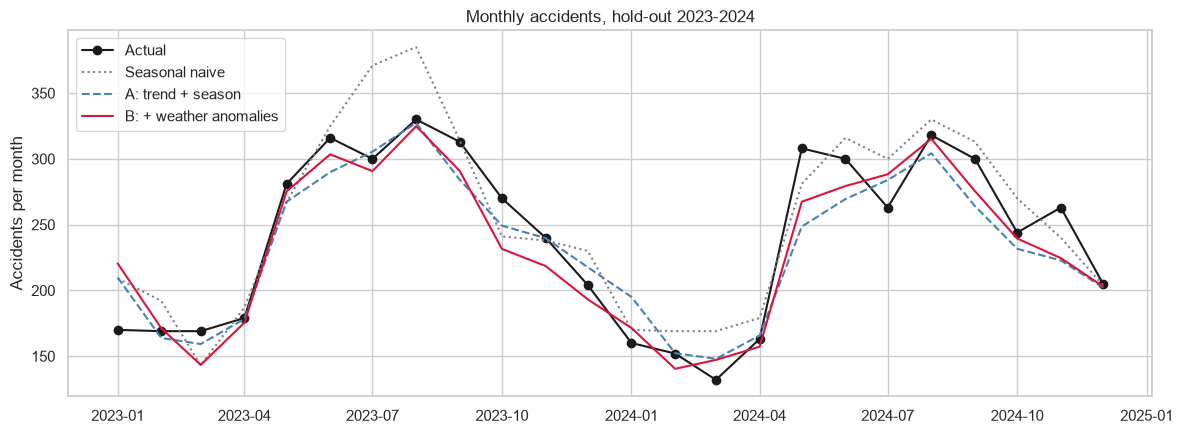

In [47]:
x = pd.to_datetime(dict(year=month_test["vuosi"], month=month_test["kuukausi"], day=1))
plt.figure(figsize=(12, 4.5))
plt.plot(x, month_test["onnettomuudet"], "ko-", label="Actual")
plt.plot(x, month_test["ennuste_naiivi"], ":", color="grey", label="Seasonal naive")
plt.plot(x, month_test["ennuste_A"], "--", color="steelblue", label="A: trend + season")
plt.plot(x, month_test["ennuste_B"], "-", color="crimson", label="B: + weather anomalies")
plt.title("Monthly accidents, hold-out 2023-2024")
plt.ylabel("Accidents per month"); plt.legend(); plt.tight_layout(); plt.show()

In [48]:
# Fitted weather effects (final descriptive model, all 120 months).
# Interpretation: multiplicative change of the expected monthly count for +1 standard deviation of the anomaly.
X_all, _, cols_all = month_features(df_month, df_month, with_weather=True)
model_all = poisson_model().fit(X_all, df_month["onnettomuudet"])
coefs = pd.Series(model_all[-1].coef_, index=cols_all)
effects = (np.exp(coefs[[c for c in cols_all if c.endswith("_poik")]]) - 1) * 100
display(effects.round(1).to_frame("% change in monthly accidents per +1 SD"))

,% change in monthly accidents per +1 SD
keski_lampotila_poik,3.3
sade_summa_poik,-1.8
lumensyvyys_poik,-2.2


### 5.2 RQ2 – does weather help to predict severe accidents?

In [49]:
def top_share_recall(y_true, score, share=0.25):
    # Share of all severe accidents found among the `share` highest-risk accidents (random = `share`).
    k = int(len(score) * share)
    top = np.argsort(score)[::-1][:k]
    return y_true[top].sum() / y_true.sum()

rows = [{"model": "Random guessing", "ROC-AUC": 0.5, "PR-AUC": y_test.mean(), "recall in top 25 %": 0.25}]
for name, s in scores.items():
    rows.append({"model": name,
                 "ROC-AUC": roc_auc_score(y_test, s),
                 "PR-AUC": average_precision_score(y_test, s),
                 "recall in top 25 %": top_share_recall(y_test, s)})
metrics = pd.DataFrame(rows).set_index("model")
display(metrics.round(3))

,ROC-AUC,PR-AUC,recall in top 25 %
model,,,
Random guessing,0.500,0.158,0.250
LogReg – no weather,0.671,0.287,0.438
LogReg + weather,0.668,0.286,0.429
HistGB – no weather,0.693,0.315,0.460
HistGB + weather,0.689,0.319,0.456


In [50]:
# Does adding weather help? Cluster bootstrap over test MONTHS (accidents of one month share the
# same weather values, so resampling single accidents would make the result look too certain).
def bootstrap_delta_auc(s_without, s_with, n_boot=300, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    groups = df_test.groupby(["vuosi", "kuukausi"]).indices
    keys = list(groups)
    diffs = []
    for _ in range(n_boot):
        pick = rng.integers(0, len(keys), len(keys))
        idx = np.concatenate([groups[keys[i]] for i in pick])
        if y_test[idx].min() == y_test[idx].max():
            continue
        diffs.append(roc_auc_score(y_test[idx], s_with[idx]) - roc_auc_score(y_test[idx], s_without[idx]))
    return np.percentile(diffs, [2.5, 50, 97.5])

for family in ["LogReg", "HistGB"]:
    lo, med, hi = bootstrap_delta_auc(scores[f"{family} – no weather"], scores[f"{family} + weather"])
    verdict = "weather helps" if lo > 0 else ("weather hurts" if hi < 0 else "no clear difference")
    print(f"{family:7s} ΔROC-AUC (with - without weather): {med:+.3f}  95 % CI [{lo:+.3f}, {hi:+.3f}]  -> {verdict}")

LogReg  ΔROC-AUC (with - without weather): -0.003  95 % CI [-0.005, -0.001]  -> weather hurts
HistGB  ΔROC-AUC (with - without weather): -0.004  95 % CI [-0.009, +0.000]  -> no clear difference


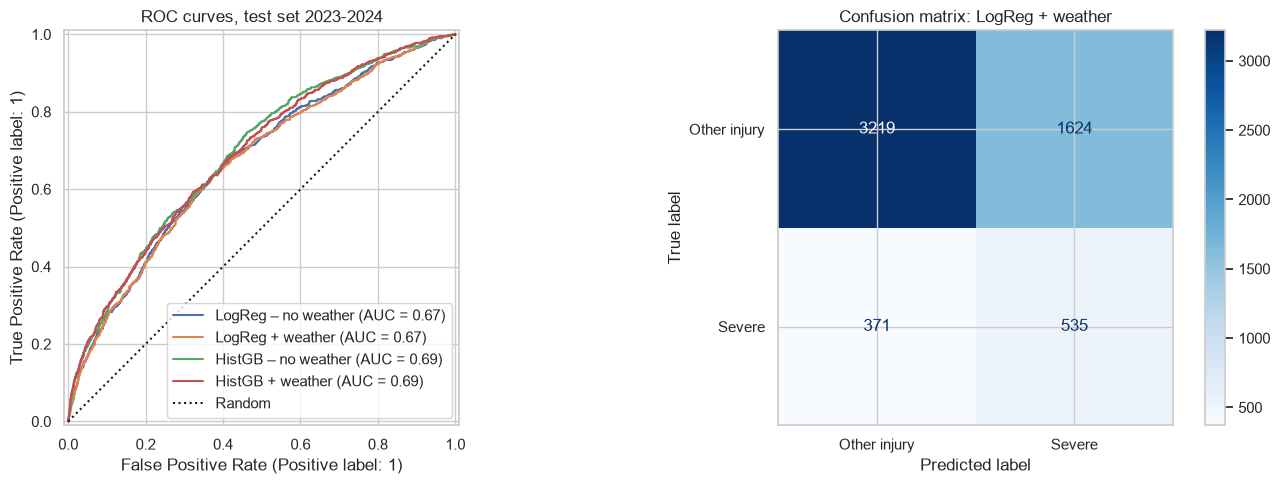

              precision    recall  f1-score   support

Other injury       0.90      0.66      0.76      4843
      Severe       0.25      0.59      0.35       906

    accuracy                           0.65      5749
   macro avg       0.57      0.63      0.56      5749
weighted avg       0.79      0.65      0.70      5749



In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, s in scores.items():
    RocCurveDisplay.from_predictions(y_test, s, name=name, ax=axes[0])
axes[0].plot([0, 1], [0, 1], "k:", label="Random")
axes[0].set_title("ROC curves, test set 2023-2024"); axes[0].legend(loc="lower right")

best_name = "LogReg + weather"
pred = (scores[best_name] >= 0.5).astype(int)          # class_weight='balanced' -> 0.5 is a sensible cut-off
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["Other injury", "Severe"],
                                        cmap="Blues", ax=axes[1])
axes[1].set_title(f"Confusion matrix: {best_name}")
plt.tight_layout(); plt.show()

print(classification_report(y_test, pred, target_names=["Other injury", "Severe"]))

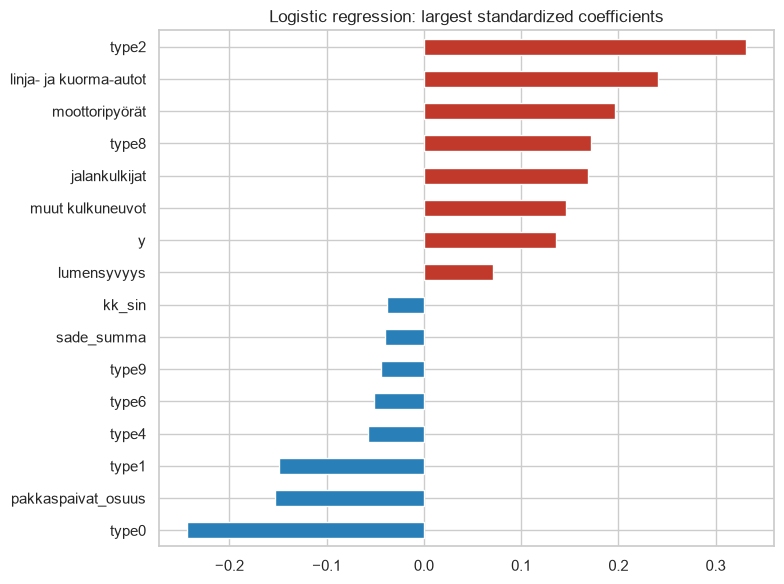

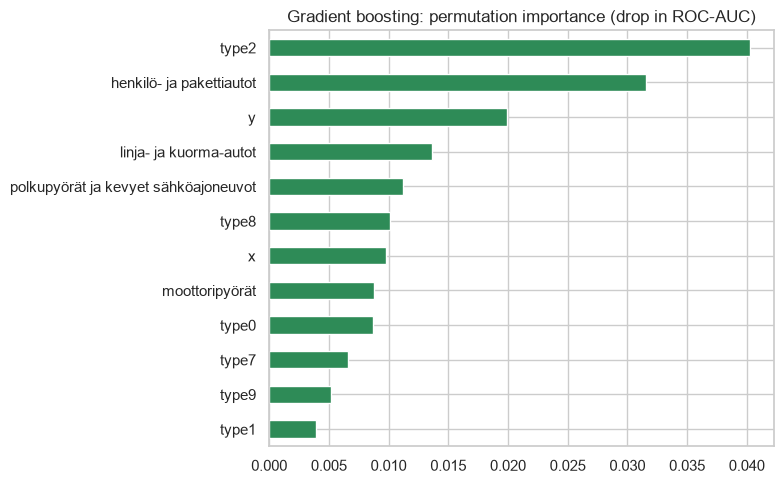

Weather features among the top 12: []


In [52]:
# What drives the predictions?
feats_w = ACC_FEATURES + WX_FEATURES

# Logistic regression: standardized coefficients (positive = higher risk of a severe accident)
coef = pd.Series(fitted["LogReg + weather"][-1].coef_[0], index=feats_w).sort_values()
top = pd.concat([coef.head(8), coef.tail(8)])
plt.figure(figsize=(8, 6))
top.plot.barh(color=["#c0392b" if v > 0 else "#2980b9" for v in top.values])
plt.title("Logistic regression: largest standardized coefficients"); plt.tight_layout(); plt.show()

# Gradient boosting: permutation importance on the test set (drop in ROC-AUC when a feature is shuffled)
perm = permutation_importance(fitted["HistGB + weather"], df_test[feats_w], y_test,
                              scoring="roc_auc", n_repeats=5, random_state=RANDOM_STATE)
imp = pd.Series(perm.importances_mean, index=feats_w).sort_values(ascending=False).head(12)
plt.figure(figsize=(8, 5))
imp[::-1].plot.barh(color="seagreen")
plt.title("Gradient boosting: permutation importance (drop in ROC-AUC)"); plt.tight_layout(); plt.show()

print("Weather features among the top 12:", [f for f in imp.index if f in WX_FEATURES])

### 5.3 Interpretation (complete after running the notebook)
Use the outputs above to answer, in your own words and with the actual numbers:

1. **H1 (winter → severe accidents):** In section 2.3, is the severe share highest in winter months? What do the weather coefficients / importances in 5.2 say about cold, snow and frost days?
2. **H2 / RQ1:** Did model B beat model A on the hold-out *and* in most rolling-origin years? What is the size of the improvement in accidents per month, and how large are the fitted weather effects?
3. **RQ2:** Is ΔROC-AUC from adding weather clearly different from zero (confidence interval)? Which accident features (vehicle groups, type, hour) dominate?
4. **Success criteria (1.4):** met or not met, for each research question.

**Limitations to mention in the report**
- Weather is a national monthly average, but accidents are local and happen on single days; a bad snowstorm in one week is invisible at this resolution.
- No traffic-volume data: more driving means more accidents regardless of weather (summer has the most accidents, not winter).
- 2020 (COVID-19) distorts the long-term trend; accident reporting practices may also have changed during the period.
- Vehicle counts and accident type are only known *after* an accident, so the severity model explains what is associated with severe accidents rather than being a real-time warning system.
- Correlation is not causation.

## 6. Deployment
**How the results can be used** (to be confirmed by the findings in section 5)
- **Resource planning:** if weather anomalies improve the monthly forecast, rescue services and road-safety authorities can combine the seasonal forecast with the weather outlook to plan resources and campaigns (for example motorcycle safety in early summer, speed and tyre campaigns in autumn and winter).
- **Prioritising prevention:** the accident characteristics that are most strongly associated with severe outcomes (for example accident type, vulnerable road users, night-time) show where prevention has the largest effect.
- **Reproducibility:** the weather download is cached in `datasets/fmi_cache/`; deleting a monthly file re-downloads only that month.

**Next steps / improvements**
1. Use the **nearest FMI station** for each accident (accident coordinates are available; FMI returns station coordinates in `obs.location_metadata`) instead of one national value.
2. Add **traffic volume** (exposure) data, for example from Fintraffic / Digitraffic automatic traffic counters, so that accident *risk* instead of the accident *count* is modeled.
3. Add an explicit COVID-19 indicator for 2020–2021.
4. Obtain exact accident dates from the source registry to move from monthly to daily weather.